### This notebook gets you started accessing, loading and plotting the spacecraft datasets we will be using this summer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('./orbitals_download/')
import helpers
import pandas as pd
import datetime as datetime
from mpl_toolkits.mplot3d import Axes3D

Step 1 : Go to the REU data google drive folder (https://drive.google.com/drive/folders/1qfIYfmeEQvrCgLsI99tbIJg-CmZaX12a?usp=drive_link), download all the CSV files, and place them in the ./data/ folder in this REU repository. If they're in the right place, the next cell should print them correctly

In [3]:
enc=2
df = pd.read_csv(f'../data/E{enc:02d}.csv')
df.columns = [col.replace('–', '_').replace('-', '_').strip() for col in df.columns]
print(df.head())

   Unnamed: 0                Times  Np_Parker  Vpr_Parker  Vpt_Parker  \
0        9317  2019-01-20 01:22:30        NaN         NaN         NaN   
1        9318  2019-01-20 01:37:30        NaN         NaN         NaN   
2        9319  2019-01-20 01:52:30        NaN         NaN         NaN   
3        9320  2019-01-20 02:07:30        NaN         NaN         NaN   
4        9321  2019-01-20 02:22:30        NaN         NaN         NaN   

   Vpn_Parker  Tp_Parker  Na_Parker  Var_Parker  Vat_Parker  ...  Ta_L1  \
0         NaN        NaN        NaN         NaN         NaN  ...    NaN   
1         NaN        NaN        NaN         NaN         NaN  ...    NaN   
2         NaN        NaN        NaN         NaN         NaN  ...    NaN   
3         NaN        NaN        NaN         NaN         NaN  ...    NaN   
4         NaN        NaN        NaN         NaN         NaN  ...    NaN   

      Br_L1     Bt_L1     Bn_L1      B_L1   thetaB_L1     phiB_L1        R_L1  \
0 -1.064087  2.541497 -0.3781

In [4]:
def get_prograde_df(encounter_number): 
    """
    returns a df containing time, longitude, radius, latitude, and radial velocity
    for the prograde portion of a given PSP encounter.
    """
    df = pd.read_csv(f'../data/E{encounter_number:02d}.csv')
    df.columns = [col.replace('-', '_').replace('—', '_').strip() for col in df.columns]
    df['Times'] = pd.to_datetime(df['Times'], errors='coerce')
    df = df.dropna(subset=['Times', 'Vpr_Parker', 'Lon_Parker', 'Lat_Parker', 'R_Parker'])

    # Identify prograde motion and apply longitude filter
    df['prograde'] = (df['Lon_Parker'].diff() > 0) & (df['Lon_Parker'].diff() < 180)
    prograde_df = df.loc[df['prograde'] == True]

    # Select and rename relevant columns
    result = prograde_df[['Times', 'Lon_Parker', 'R_Parker', 'Lat_Parker', 'Vpr_Parker']]
    result = result.rename(columns={
        'Times': 'time',
        'Lon_Parker': 'longitude',
        'R_Parker': 'radius',
        'Lat_Parker': 'latitude',
        'Vpr_Parker': 'Vr'
    })

    return result
                                    

In [5]:
y_original = get_prograde_df(2)['longitude']

In [6]:
y_new = helpers.roll_to_180(y_original) #prevents the jump across (360-0) boundary in longitude

In [7]:
pd.set_option('display.max_rows', None)

#print(get_prograde_df(22))

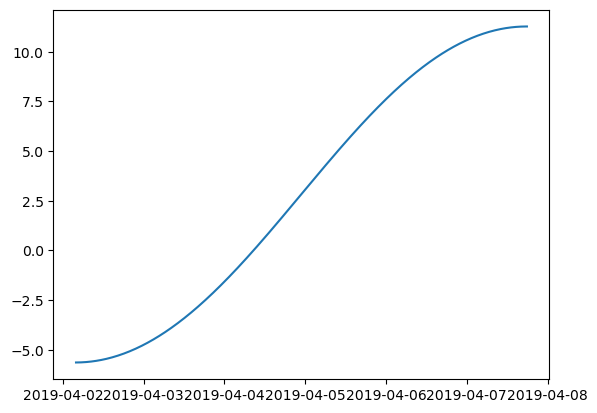

In [27]:
plt.plot(get_prograde_df(2)['time'], helpers.roll_to_180(get_prograde_df(2)['longitude']))

Text(0, 0.5, 'Vr (km/s)')

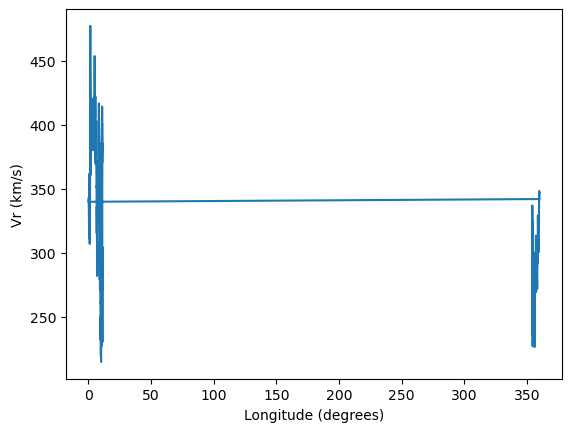

In [28]:
df = get_prograde_df(2)
fig,ax = plt.subplots()
ax.plot(df['longitude'],df['Vr'])
ax.set_xlabel('Longitude (degrees)')
ax.set_ylabel('Vr (km/s)')

In [29]:
# if we ever wanted to export to csv? 
#df_prograde = get_prograde_df(21)
#df_prograde.to_csv('prograde_E21.csv', index=False) # no row numbers

In [30]:
ls ../data

E01.csv                E09.csv                E17.csv
E02.csv                E10.csv                E18.csv
E03.csv                E11.csv                E19.csv
E04.csv                E12.csv                E20.csv
E05.csv                E13.csv                E21.csv
E06.csv                E14.csv                E22.csv
E07.csv                E15.csv                E23.csv
E08.csv                E16.csv                the_models_2025-05-01


Step 2 : Open one of these files in this notebook (we like to use `pandas`) and see if you understand what the contents are and how they are organized. Ask us any questions about what you don't understand! 

In [31]:
enc=2
df = pd.read_csv(f'../data/E{enc:02d}.csv')
df.columns = [col.replace('–', '_').replace('-', '_').strip() for col in df.columns]
print(df.head())

   Unnamed: 0                Times  Np_Parker  Vpr_Parker  Vpt_Parker  \
0        9317  2019-01-20 01:22:30        NaN         NaN         NaN   
1        9318  2019-01-20 01:37:30        NaN         NaN         NaN   
2        9319  2019-01-20 01:52:30        NaN         NaN         NaN   
3        9320  2019-01-20 02:07:30        NaN         NaN         NaN   
4        9321  2019-01-20 02:22:30        NaN         NaN         NaN   

   Vpn_Parker  Tp_Parker  Na_Parker  Var_Parker  Vat_Parker  ...  Ta_L1  \
0         NaN        NaN        NaN         NaN         NaN  ...    NaN   
1         NaN        NaN        NaN         NaN         NaN  ...    NaN   
2         NaN        NaN        NaN         NaN         NaN  ...    NaN   
3         NaN        NaN        NaN         NaN         NaN  ...    NaN   
4         NaN        NaN        NaN         NaN         NaN  ...    NaN   

      Br_L1     Bt_L1     Bn_L1      B_L1   thetaB_L1     phiB_L1        R_L1  \
0 -1.064087  2.541497 -0.3781

Step 3 : Try plotting the Parker Solar Probe measurements of velocity vs time

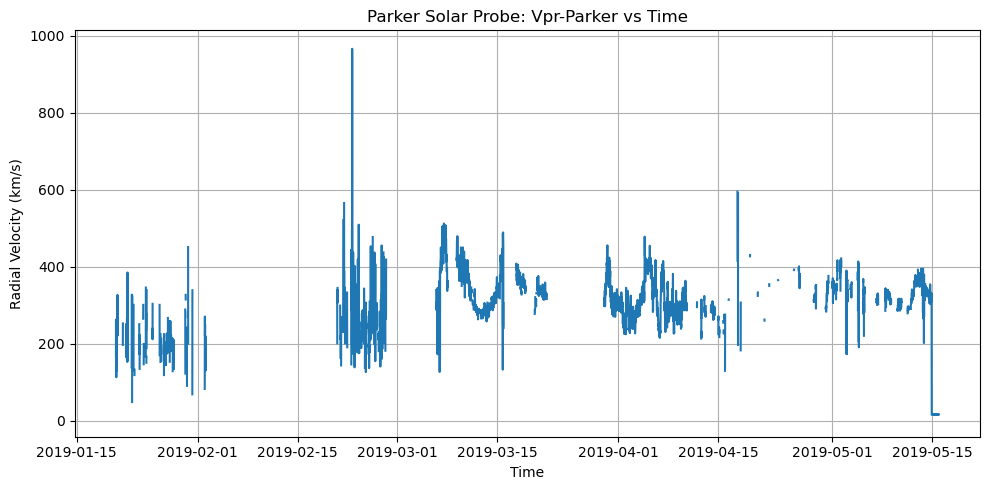

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# convert to datetime
df['Times'] = pd.to_datetime(df['Times'])

# plot Vpr-Parker vs Time
plt.figure(figsize=(10, 5))
plt.plot(df['Times'], df['Vpr_Parker'])
plt.xlabel('Time')
plt.ylabel('Radial Velocity (km/s)')
plt.title('Parker Solar Probe: Vpr-Parker vs Time')
plt.grid(True)
plt.tight_layout()
plt.show()


Step 4 : Try plotting the Parker Solar Probe trajectory. Note the coordinates are in spherical polar coordinates, try to convert to cartesian coordinates and plotting X vs Y to see what the orbit looks like from above. 

In [33]:
df.columns.tolist()

['Unnamed: 0',
 'Times',
 'Np_Parker',
 'Vpr_Parker',
 'Vpt_Parker',
 'Vpn_Parker',
 'Tp_Parker',
 'Na_Parker',
 'Var_Parker',
 'Vat_Parker',
 'Van_Parker',
 'Ta_Parker',
 'Br_Parker',
 'Bt_Parker',
 'Bn_Parker',
 'B_Parker',
 'thetaB_Parker',
 'phiB_Parker',
 'R_Parker',
 'Lon_Parker',
 'Lat_Parker',
 'Np_SolO',
 'Vpr_SolO',
 'Vpt_SolO',
 'Vpn_SolO',
 'Tp_SolO',
 'Br_SolO',
 'Bt_SolO',
 'Bn_SolO',
 'B_SolO',
 'thetaB_SolO',
 'phiB_SolO',
 'R_SolO',
 'Lon_SolO',
 'Lat_SolO',
 'Np_L1',
 'Vpr_L1',
 'Vpt_L1',
 'Vpn_L1',
 'Tp_L1',
 'Na_L1',
 'Var_L1',
 'Vat_L1',
 'Van_L1',
 'Ta_L1',
 'Br_L1',
 'Bt_L1',
 'Bn_L1',
 'B_L1',
 'thetaB_L1',
 'phiB_L1',
 'R_L1',
 'Lon_L1',
 'Lat_L1']

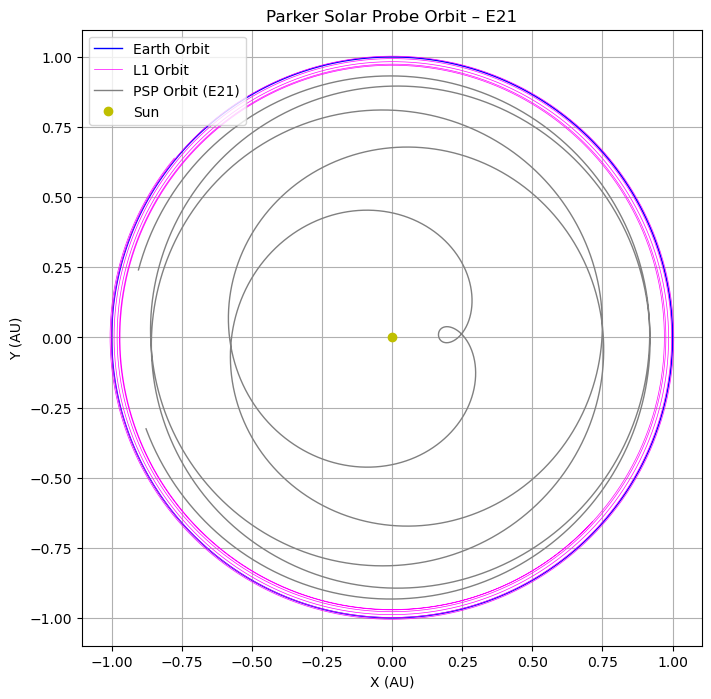

In [34]:

# load and clean encounter data
df = pd.read_csv(f'../data/E{enc:02d}.csv')
df.columns = [col.replace('–', '_').replace('-', '_').strip() for col in df.columns]
df = df.dropna(subset=['Lon_Parker', 'Lat_Parker', 'R_Parker']) 

# identify prograde motion (where longitude increases)
#df['prograde'] = df['Lon_Parker'].diff() > 0
# prograde_df = df[df['prograde'] == True]

# convert spherical to Cartesian
lon = np.deg2rad(df['Lon_Parker'])
lat = np.deg2rad(df['Lat_Parker'])
#lon_prograde = np.deg2rad(prograde_df['Lon_Parker'])
#lat_prograde = np.deg2rad(prograde_df['Lat_Parker'])                       

r = df['R_Parker'] / 215.0  # convert solar radii to AU
x = r * np.cos(lat) * np.cos(lon)
y = r * np.cos(lat) * np.sin(lon)

#r_prograde = prograde_df['R_Parker'] / 215.0  # convert solar radii to AU
#x_prograde = r * np.cos(lat_prograde) * np.cos(lon_prograde)
#y_prograde = r * np.cos(lat_prograde) * np.sin(lon_prograde)


# earth orbit
theta = np.linspace(0, 2 * np.pi, 300)
earth_x = np.cos(theta)
earth_y = np.sin(theta)

# converting r_L1 spherical coordinates to AU
lon_L1 = np.deg2rad(df['Lon_L1'])
lat_L1 = np.deg2rad(df['Lat_L1'])
r_L1   = df['R_L1'] / 215.0  # solar radii → AU
x_L1 = r_L1 * np.cos(lat_L1) * np.cos(lon_L1)
y_L1 = r_L1 * np.cos(lat_L1) * np.sin(lon_L1)

# plot 3d model


# plotting all orbits
plt.figure(figsize=(8, 8))
plt.plot(earth_x, earth_y, linestyle='-', lw=1, color='blue',label='Earth Orbit')
plt.plot(x_L1, y_L1, color='magenta', alpha=1, lw=0.5, label='L1 Orbit')
plt.plot(x, y, color='gray', lw=1,label='PSP Orbit (E21)')
#plt.plot(x_prograde, y_prograde, color='black', lw=2,alpha=1,label='Prograde PSP (E21)')
plt.plot(0, 0, 'yo', label='Sun')  # Sun at origin
plt.xlabel('X (AU)')
plt.ylabel('Y (AU)')
plt.title('Parker Solar Probe Orbit – E21')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


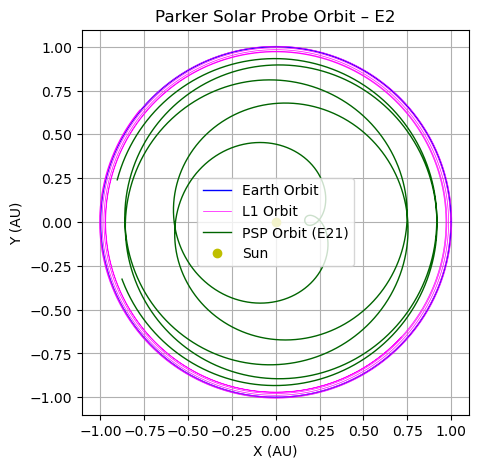

In [35]:
# plotting all orbits
plt.figure(figsize=(5, 5))
plt.plot(earth_x, earth_y, linestyle='-', lw=1, color='blue',label='Earth Orbit')
plt.plot(x_L1, y_L1, color='magenta', alpha=1, lw=0.5, label='L1 Orbit')
plt.plot(x, y, color='darkgreen', lw=1,label='PSP Orbit (E21)')
plt.plot(0, 0, 'yo', label='Sun')  # Sun at origin
plt.xlabel('X (AU)')
plt.ylabel('Y (AU)')
plt.title('Parker Solar Probe Orbit – E2')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

Step 5 : Plot the velocity measurements vs longitude

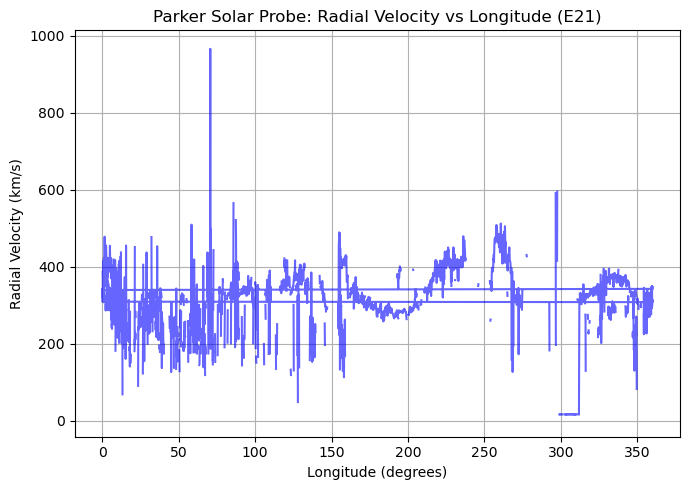

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(df['Lon_Parker'], df['Vpr_Parker'],color='blue', alpha=0.6)
plt.xlabel('Longitude (degrees)')
plt.ylabel('Radial Velocity (km/s)')
plt.title('Parker Solar Probe: Radial Velocity vs Longitude (E21)')
plt.grid(True)
plt.tight_layout()
plt.show()

Step 6: Design a filter that lets you select all data points between a start and an end datetime. Plot the original full timeseries faintly with your filtered range over it in bold

In [37]:
#print(df['Times'])

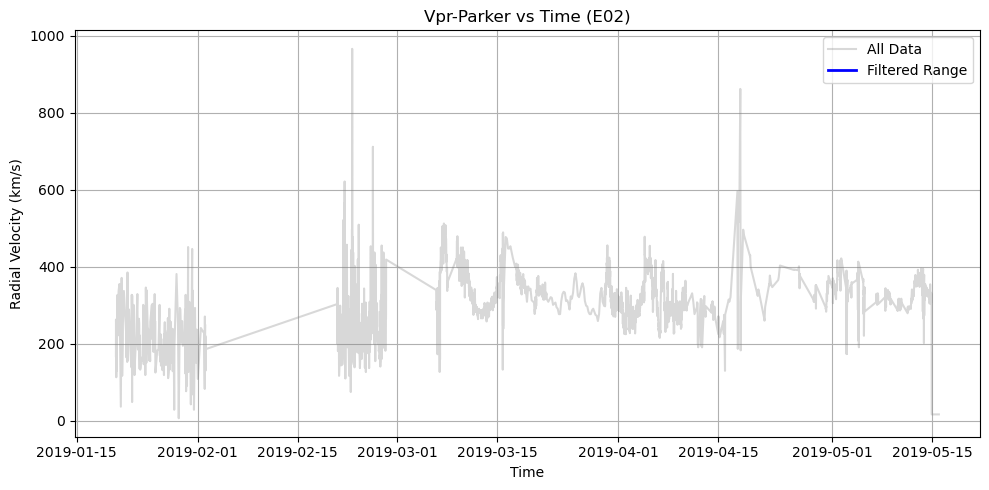

In [38]:
from datetime import datetime
df.columns = [col.replace('-', '_').replace('–', '_').strip() for col in df.columns]
df['Times'] = pd.to_datetime(df['Times'], errors='coerce')
df = df.dropna(subset=['Times', 'Vpr_Parker'])

start_time = datetime(2024, 10, 20)
end_time   = datetime(2024, 11, 1)
filtered = df[(df['Times'] >= start_time) & (df['Times'] <= end_time)]


# plot
plt.figure(figsize=(10, 5))
plt.plot(df['Times'], df['Vpr_Parker'], color='gray', alpha=0.3, label='All Data')
plt.plot(filtered['Times'], filtered['Vpr_Parker'], color='blue', linewidth=2, label='Filtered Range')
plt.xlabel('Time')
plt.ylabel('Radial Velocity (km/s)')
plt.title(f'Vpr-Parker vs Time (E{enc:02d})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Step 7 : Figure out the date ranges when Parker was moving prograde with respect to the Sun.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# load and clean
df = pd.read_csv(f'../data/E{enc:02d}.csv')
df.columns = [col.replace('–', '_').replace('-', '_') for col in df.columns]

# convert Times column
df['Times'] = pd.to_datetime(df['Times'], errors='coerce')

# drop rows with missing key values
df = df.dropna(subset=['Times', 'Vpr_Parker', 'Lon_Parker'])

# rename 
#df = df.rename(columns={'Vpr_Parker': 'v', 'Lon_Parker': 'lon'})

# identify prograde motion (where longitude increases)
df['prograde'] = df['Lon_Parker'].diff() > 0
prograde_df = df[df['prograde'] == True]

# preview and plot
print(prograde_df['Times'].values[0])
print(prograde_df['Times'].values[-1])

#print(prograde_df)

2019-02-01T10:22:30.000000000
2019-05-11T13:52:30.000000000


Step 8 : Repeat the velocity vs longitude plot with the prograde longitudes only

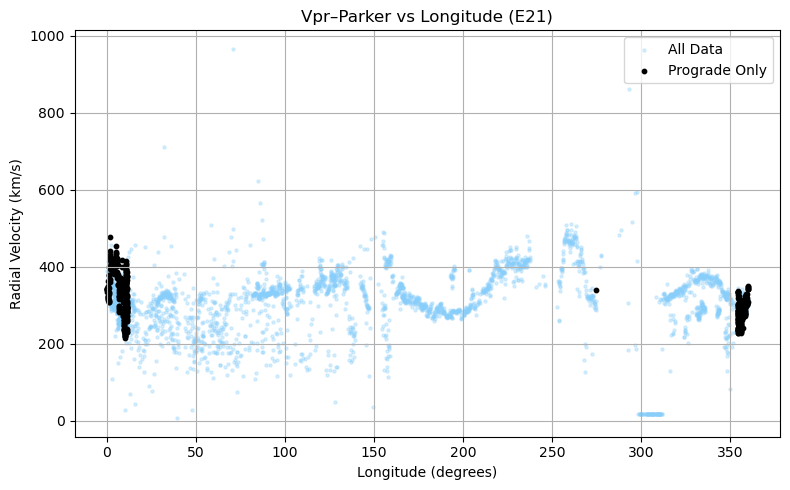

In [40]:
# plot all the data faintly
plt.figure(figsize=(8, 5))
plt.scatter(df['Lon_Parker'], df['Vpr_Parker'], s=5, color='lightskyblue', alpha=0.3, label='All Data')

# highlight the prograde in black
plt.scatter(prograde_df['Lon_Parker'], prograde_df['Vpr_Parker'], s=10, color='black', label='Prograde Only')

plt.xlabel('Longitude (degrees)')
plt.ylabel('Radial Velocity (km/s)')
plt.title('Vpr–Parker vs Longitude (E21)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


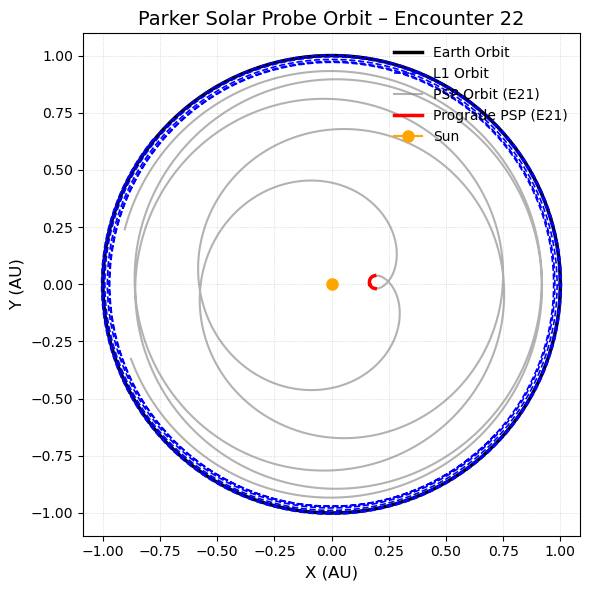

In [41]:

# load and clean encounter data
df = pd.read_csv(f'../data/E{enc:02d}.csv')
df.columns = [col.replace('–', '_').replace('-', '_').strip() for col in df.columns]
df = df.dropna(subset=['Lon_Parker', 'Lat_Parker', 'R_Parker']) 

# identify prograde motion (where longitude increases)
df['prograde'] = df['Lon_Parker'].diff() > 0
prograde_df = df[df['prograde'] == True]

# convert spherical to Cartesian
lon = np.deg2rad(df['Lon_Parker'])
lat = np.deg2rad(df['Lat_Parker'])
lon_prograde = np.deg2rad(prograde_df['Lon_Parker'])
lat_prograde = np.deg2rad(prograde_df['Lat_Parker'])                       

r = df['R_Parker'] / 215.0  # convert solar radii to AU
x = r * np.cos(lat) * np.cos(lon)
y = r * np.cos(lat) * np.sin(lon)

r_prograde = prograde_df['R_Parker'] / 215.0  # convert solar radii to AU
x_prograde = r * np.cos(lat_prograde) * np.cos(lon_prograde)
y_prograde = r * np.cos(lat_prograde) * np.sin(lon_prograde)


# earth orbit
theta = np.linspace(0, 2 * np.pi, 300)
earth_x = np.cos(theta)
earth_y = np.sin(theta)

# converting r_L1 spherical coordinates to AU
lon_L1 = np.deg2rad(df['Lon_L1'])
lat_L1 = np.deg2rad(df['Lat_L1'])
r_L1   = df['R_L1'] / 215.0  # solar radii → AU
x_L1 = r_L1 * np.cos(lat_L1) * np.cos(lon_L1)
y_L1 = r_L1 * np.cos(lat_L1) * np.sin(lon_L1)

# plot 3d model


import matplotlib.pyplot as plt

# Plot all orbits with improved style
plt.figure(figsize=(6, 6))
plt.plot(earth_x, earth_y, linestyle='-', linewidth=2.5, color='black', label='Earth Orbit')
plt.plot(x_L1, y_L1, linestyle='--', linewidth=1.2, color='blue', label='L1 Orbit')
plt.plot(x, y, linestyle='-', linewidth=1.5, color='grey', alpha=0.6, label='PSP Orbit (E21)')
plt.plot(x_prograde, y_prograde, linestyle='-', linewidth=2.5, color='red', label='Prograde PSP (E21)')
plt.plot(0, 0, marker='o', color='orange', markersize=8, label='Sun')

# Axis settings
plt.xlabel('X (AU)', fontsize=12)
plt.ylabel('Y (AU)', fontsize=12)
plt.title('Parker Solar Probe Orbit – Encounter 22', fontsize=14)
plt.axis('equal')
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Legend
plt.legend(loc='upper right', frameon=False, fontsize=10)

# Tight layout for better spacing
plt.tight_layout()
plt.show()
